In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/__results__.html
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/final_waste_research_metadata_v1.0.zip
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/__notebook__.ipynb
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/__output__.json
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/custom.css
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/metadata/test_bangladesh.csv
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/metadata/validation.csv
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/metadata/test_international.csv
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/metadata/train.csv
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset_Split/metadata/test.csv
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset

In [2]:
# ============================================================
# EfficientNet-B0 RESEARCH PIPELINE
# STEP 00 — IMPORTS
# ============================================================

import os
import gc
import json
import random
import shutil
import time
import math
import warnings

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torchvision.models import (
    densenet121,
    DenseNet121_Weights
)

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)

warnings.filterwarnings("ignore")

print("=" * 80)
print("EfficientNet-B0 RESEARCH PIPELINE")
print("=" * 80)

print("PyTorch     :", torch.__version__)
print("TorchVision :", torchvision.__version__)

EfficientNet-B0 RESEARCH PIPELINE
PyTorch     : 2.10.0+cu128
TorchVision : 0.25.0+cu128


In [3]:
# ============================================================
# STEP 01 — TRAINING ENVIRONMENT
# ============================================================

print("=" * 80)
print("TRAINING ENVIRONMENT")
print("=" * 80)

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU             :", torch.cuda.get_device_name(0))

    gpu_memory = (
        torch.cuda.get_device_properties(0).total_memory
        / (1024 ** 3)
    )

    print(
        f"GPU Memory      : {gpu_memory:.2f} GB"
    )

    DEVICE = torch.device("cuda")

else:

    print("⚠️ CUDA GPU NOT AVAILABLE")

    DEVICE = torch.device("cpu")

print("\nUsing device:", DEVICE)

TRAINING ENVIRONMENT
PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
GPU Memory      : 14.56 GB

Using device: cuda


In [4]:
# ============================================================
# STEP 02 — REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("✓ Random seed:", SEED)

✓ Random seed: 42


In [5]:
# ============================================================
# STEP 03 — PATH DISCOVERY
# ============================================================

KAGGLE_INPUT = Path("/kaggle/input")
KAGGLE_WORKING = Path("/kaggle/working")

print("=" * 80)
print("SEARCHING FOR FINAL DATASET")
print("=" * 80)

metadata_candidates = list(
    KAGGLE_INPUT.rglob("Final_Waste_Dataset/research_metadata")
)

if not metadata_candidates:

    metadata_candidates = list(
        KAGGLE_INPUT.rglob("research_metadata")
    )

print("\nMetadata candidates:")

for p in metadata_candidates:
    print("→", p)

if not metadata_candidates:

    raise FileNotFoundError(
        "Final_Waste_Dataset/research_metadata not found."
    )

META = metadata_candidates[0]

print("\nSelected META:")
print(META)

SEARCHING FOR FINAL DATASET

Metadata candidates:
→ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata

Selected META:
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata


In [6]:
# ============================================================
# STEP 04 — IMAGE ROOT DISCOVERY
# ============================================================

possible_image_roots = []

for root in [
    KAGGLE_INPUT,
    KAGGLE_WORKING
]:

    if root.exists():

        for p in root.rglob("images"):

            if not p.is_dir():
                continue

            try:

                classes_found = {
                    x.name
                    for x in p.iterdir()
                    if x.is_dir()
                }

            except Exception:

                continue

            required = {
                "Cardboard",
                "Glass",
                "Metal",
                "Paper",
                "Plastic"
            }

            if required.issubset(classes_found):

                possible_image_roots.append(p)

print("=" * 80)
print("IMAGE ROOT CANDIDATES")
print("=" * 80)

for p in possible_image_roots:

    print("→", p)

if not possible_image_roots:

    raise FileNotFoundError(
        "Could not find image root containing all 5 classes."
    )

IMAGE_ROOT = possible_image_roots[0]

print("\nIMAGE_ROOT:")
print(IMAGE_ROOT)

IMAGE ROOT CANDIDATES
→ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/images

IMAGE_ROOT:
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/images


In [7]:
# ============================================================
# STEP 05 — METADATA PATHS
# ============================================================

FINAL_METADATA = META / "final_metadata.csv"
TRAIN_METADATA = META / "train_final.csv"
VAL_METADATA = META / "validation_final.csv"
TEST_METADATA = META / "test_final.csv"

BD_TEST_METADATA = META / "test_bangladesh_final.csv"
INTL_TEST_METADATA = META / "test_international_final.csv"

required_files = [
    FINAL_METADATA,
    TRAIN_METADATA,
    VAL_METADATA,
    TEST_METADATA,
    BD_TEST_METADATA,
    INTL_TEST_METADATA
]

print("=" * 80)
print("METADATA FILE CHECK")
print("=" * 80)

for p in required_files:

    if p.exists():

        print("✓", p)

    else:

        print("✗", p)
        raise FileNotFoundError(p)

METADATA FILE CHECK
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/final_metadata.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/train_final.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/validation_final.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/test_final.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/test_bangladesh_final.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/test_international_final.csv


In [8]:
# ============================================================
# STEP 06 — LOAD METADATA
# ============================================================

final_df = pd.read_csv(FINAL_METADATA)
train_df = pd.read_csv(TRAIN_METADATA)
val_df = pd.read_csv(VAL_METADATA)
test_df = pd.read_csv(TEST_METADATA)

bd_test_original = pd.read_csv(BD_TEST_METADATA)
intl_test_original = pd.read_csv(INTL_TEST_METADATA)

print("=" * 80)
print("DATASET LOADED")
print("=" * 80)

print("Final       :", len(final_df))
print("Train       :", len(train_df))
print("Validation  :", len(val_df))
print("Test        :", len(test_df))
print("BD CSV      :", len(bd_test_original))
print("Intl CSV    :", len(intl_test_original))

DATASET LOADED
Final       : 10668
Train       : 7245
Validation  : 1552
Test        : 1871
BD CSV      : 319
Intl CSV    : 1289


In [9]:
# ============================================================
# STEP 07 — METADATA COLUMN AUDIT
# ============================================================

print("=" * 80)
print("METADATA COLUMN AUDIT")
print("=" * 80)

datasets = {
    "final": final_df,
    "train": train_df,
    "validation": val_df,
    "test": test_df,
    "bangladesh_original": bd_test_original,
    "international_original": intl_test_original
}

required_columns = [
    "filename",
    "class",
    "source",
    "country",
    "dataset_group",
    "original_path"
]

for name, df in datasets.items():

    print(f"\n{name.upper()}")

    print(df.columns.tolist())

    missing_columns = [
        c for c in required_columns
        if c not in df.columns
    ]

    if missing_columns:

        raise ValueError(
            f"{name} missing columns: {missing_columns}"
        )

print("\n✓ Metadata schema valid")

METADATA COLUMN AUDIT

FINAL
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

TRAIN
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

VALIDATION
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

TEST
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

BANGLADESH_ORIGINAL
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

INTERNATIONAL_ORIGINAL
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

✓ Metadata schema valid


In [10]:
# ============================================================
# STEP 08 — DATASET SPLIT AUDIT
# ============================================================

print("=" * 80)
print("DATASET COUNT AUDIT")
print("=" * 80)

print(f"Final metadata : {len(final_df):,}")
print(f"Train          : {len(train_df):,}")
print(f"Validation     : {len(val_df):,}")
print(f"Test           : {len(test_df):,}")

split_total = (
    len(train_df)
    + len(val_df)
    + len(test_df)
)

print("\nTrain + Validation + Test:", split_total)

if split_total != len(final_df):

    raise ValueError(
        "Dataset split mismatch. STOP."
    )

print("\n✓ Split totals match")

DATASET COUNT AUDIT
Final metadata : 10,668
Train          : 7,245
Validation     : 1,552
Test           : 1,871

Train + Validation + Test: 10668

✓ Split totals match


In [11]:
# ============================================================
# STEP 09 — RECONSTRUCT COMPLETE TEST GROUPS
# ============================================================

print("=" * 80)
print("RECONSTRUCTING COMPLETE TEST GROUPS")
print("=" * 80)

test_work = test_df.copy()

# ------------------------------------------------------------
# Normalize text fields
# ------------------------------------------------------------

for col in [
    "filename",
    "source",
    "country",
    "dataset_group"
]:

    test_work[col] = (
        test_work[col]
        .fillna("")
        .astype(str)
        .str.strip()
    )

# ------------------------------------------------------------
# Normalize filename
# ------------------------------------------------------------

test_work["filename_key"] = (
    test_work["filename"]
    .str.strip()
    .str.lower()
)

# ------------------------------------------------------------
# Build groups DIRECTLY from final test metadata
# ------------------------------------------------------------

bd_test_df = test_work[
    (
        test_work["source"].str.lower() == "bangladesh"
    )
    |
    (
        test_work["country"].str.lower() == "bangladesh"
    )
    |
    (
        test_work["dataset_group"].str.lower() == "bangladesh"
    )
].copy()

international_test_df = test_work[
    ~test_work["filename_key"].isin(
        set(bd_test_df["filename_key"])
    )
].copy()

# ------------------------------------------------------------
# Remove helper column later
# ------------------------------------------------------------

print("Overall test       :", len(test_work))
print("Bangladesh test    :", len(bd_test_df))
print("International test :", len(international_test_df))

print(
    "\nBD + International :",
    len(bd_test_df) + len(international_test_df)
)

if (
    len(bd_test_df)
    + len(international_test_df)
    != len(test_work)
):

    raise ValueError(
        "Test group reconstruction failed."
    )

print("\n✓ Complete test group coverage restored")

RECONSTRUCTING COMPLETE TEST GROUPS
Overall test       : 1871
Bangladesh test    : 582
International test : 1289

BD + International : 1871

✓ Complete test group coverage restored


In [12]:
# ============================================================
# STEP 09 — RECONSTRUCT COMPLETE TEST GROUPS
# ============================================================

print("=" * 80)
print("RECONSTRUCTING COMPLETE TEST GROUPS")
print("=" * 80)

test_work = test_df.copy()

# ------------------------------------------------------------
# Normalize text fields
# ------------------------------------------------------------

for col in [
    "filename",
    "source",
    "country",
    "dataset_group"
]:

    test_work[col] = (
        test_work[col]
        .fillna("")
        .astype(str)
        .str.strip()
    )

# ------------------------------------------------------------
# Normalize filename
# ------------------------------------------------------------

test_work["filename_key"] = (
    test_work["filename"]
    .str.strip()
    .str.lower()
)

# ------------------------------------------------------------
# Build groups DIRECTLY from final test metadata
# ------------------------------------------------------------

bd_test_df = test_work[
    (
        test_work["source"].str.lower() == "bangladesh"
    )
    |
    (
        test_work["country"].str.lower() == "bangladesh"
    )
    |
    (
        test_work["dataset_group"].str.lower() == "bangladesh"
    )
].copy()

international_test_df = test_work[
    ~test_work["filename_key"].isin(
        set(bd_test_df["filename_key"])
    )
].copy()

# ------------------------------------------------------------
# Remove helper column later
# ------------------------------------------------------------

print("Overall test       :", len(test_work))
print("Bangladesh test    :", len(bd_test_df))
print("International test :", len(international_test_df))

print(
    "\nBD + International :",
    len(bd_test_df) + len(international_test_df)
)

if (
    len(bd_test_df)
    + len(international_test_df)
    != len(test_work)
):

    raise ValueError(
        "Test group reconstruction failed."
    )

print("\n✓ Complete test group coverage restored")

RECONSTRUCTING COMPLETE TEST GROUPS
Overall test       : 1871
Bangladesh test    : 582
International test : 1289

BD + International : 1871

✓ Complete test group coverage restored


In [13]:
# ============================================================
# STEP 11 — CLASS CONFIGURATION
# ============================================================

CLASS_NAMES = [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]

CLASS_TO_IDX = {
    cls: idx
    for idx, cls in enumerate(CLASS_NAMES)
}

IDX_TO_CLASS = {
    idx: cls
    for cls, idx in CLASS_TO_IDX.items()
}

print("=" * 80)
print("CLASS MAPPING")
print("=" * 80)

for cls, idx in CLASS_TO_IDX.items():

    print(f"{cls:<12} : {idx}")

CLASS MAPPING
Cardboard    : 0
Glass        : 1
Metal        : 2
Paper        : 3
Plastic      : 4


In [14]:
# ============================================================
# STEP 12 — CLASS AUDIT
# ============================================================

print("=" * 80)
print("CLASS AUDIT")
print("=" * 80)

for name, df in {
    "train": train_df,
    "validation": val_df,
    "test": test_df
}.items():

    classes = sorted(
        df["class"].dropna().unique().tolist()
    )

    print(f"\n{name}:")
    print(classes)

    if set(classes) != set(CLASS_NAMES):

        raise ValueError(
            f"{name} does not contain all 5 classes."
        )

print("\n✓ All 5 classes present")

CLASS AUDIT

train:
['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']

validation:
['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']

test:
['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']

✓ All 5 classes present


In [15]:
# ============================================================
# RESTORE FINAL RESEARCH METADATA
# ============================================================

from pathlib import Path
import pandas as pd

# ------------------------------------------------------------
# CORRECT KAGGLE INPUT PATH
# ------------------------------------------------------------

META = Path(
    "/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata"
)

print("=" * 80)
print("RESTORING FINAL RESEARCH METADATA")
print("=" * 80)

print("Metadata directory:")
print(META)

# ------------------------------------------------------------
# CHECK DIRECTORY
# ------------------------------------------------------------

if not META.exists():
    raise FileNotFoundError(
        f"Metadata directory not found:\n{META}"
    )

print("\n✓ Metadata directory found")

print("\nAvailable files:")

for f in sorted(META.iterdir()):
    print(" -", f.name)

# ------------------------------------------------------------
# LOAD METADATA
# ------------------------------------------------------------

final_df = pd.read_csv(
    META / "final_metadata.csv"
)

train_df = pd.read_csv(
    META / "train_final.csv"
)

val_df = pd.read_csv(
    META / "validation_final.csv"
)

test_df = pd.read_csv(
    META / "test_final.csv"
)

bd_test = pd.read_csv(
    META / "test_bangladesh_final.csv"
)

international_test_df = pd.read_csv(
    META / "test_international_final.csv"
)

# ------------------------------------------------------------
# RESTORE SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DATASET RESTORED SUCCESSFULLY")
print("=" * 80)

print(
    f"Final metadata       : {len(final_df):,}"
)

print(
    f"Train                : {len(train_df):,}"
)

print(
    f"Validation           : {len(val_df):,}"
)

print(
    f"Overall Test         : {len(test_df):,}"
)

print(
    f"Bangladesh Test      : {len(bd_test):,}"
)

print(
    f"International Test   : {len(international_test_df):,}"
)

# ------------------------------------------------------------
# CONSISTENCY CHECK
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("CONSISTENCY CHECK")
print("-" * 80)

split_total = (
    len(train_df)
    + len(val_df)
    + len(test_df)
)

print(
    f"Train + Validation + Test : {split_total:,}"
)

print(
    f"Final metadata            : {len(final_df):,}"
)

print(
    "MATCH                     :",
    split_total == len(final_df)
)

# ------------------------------------------------------------
# BASIC DATA CHECK
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("CLASS DISTRIBUTION — TRAIN")
print("-" * 80)

print(
    train_df["class"]
    .value_counts()
    .sort_index()
)

print("\n" + "-" * 80)
print("SOURCE DISTRIBUTION — TRAIN")
print("-" * 80)

print(
    train_df["source"]
    .value_counts()
)

print("\n✓ METADATA RESTORATION COMPLETE")

RESTORING FINAL RESEARCH METADATA
Metadata directory:
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata

✓ Metadata directory found

Available files:
 - FINAL_CHECKPOINT.json
 - final_metadata.csv
 - manual_review_decisions.csv
 - test_bangladesh_final.csv
 - test_final.csv
 - test_international_final.csv
 - train_final.csv
 - training_class_balance.csv
 - validation_final.csv

DATASET RESTORED SUCCESSFULLY
Final metadata       : 10,668
Train                : 7,245
Validation           : 1,552
Overall Test         : 1,871
Bangladesh Test      : 319
International Test   : 1,289

--------------------------------------------------------------------------------
CONSISTENCY CHECK
--------------------------------------------------------------------------------
Train + Validation + Test : 10,668
Final metadata            : 10,668
MATCH                     : True

--------------------------------------------------------------------------------
CLASS

In [16]:
# ============================================================
# STEP 13 — TRAINING CLASS DISTRIBUTION
# ============================================================

train_class_counts = (
    train_df["class"]
    .value_counts()
    .reindex(CLASS_NAMES)
)

print("=" * 80)
print("TRAINING CLASS DISTRIBUTION")
print("=" * 80)

print(train_class_counts)

max_count = train_class_counts.max()
min_count = train_class_counts.min()

imbalance_ratio = max_count / min_count

print("\nMaximum:", max_count)
print("Minimum:", min_count)
print(
    f"Imbalance ratio: {imbalance_ratio:.4f}"
)

TRAINING CLASS DISTRIBUTION
class
Cardboard    1193
Glass        1433
Metal        1594
Paper        1793
Plastic      1232
Name: count, dtype: int64

Maximum: 1793
Minimum: 1193
Imbalance ratio: 1.5029


In [17]:
# ============================================================
# STEP 14 — CLASS WEIGHTS
# ============================================================

class_counts = train_class_counts.values.astype(np.float64)

total_train = class_counts.sum()
num_classes = len(CLASS_NAMES)

class_weights = (
    total_train
    / (num_classes * class_counts)
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)

print("=" * 80)
print("CLASS WEIGHTS")
print("=" * 80)

for cls, weight in zip(
    CLASS_NAMES,
    class_weights
):

    print(
        f"{cls:<12}: {weight:.4f}"
    )

CLASS WEIGHTS
Cardboard   : 1.2146
Glass       : 1.0112
Metal       : 0.9090
Paper       : 0.8081
Plastic     : 1.1761


In [18]:
# ============================================================
# STEP 15 — IMAGE PATH RESOLUTION
# ============================================================

print("=" * 80)
print("IMAGE PATH RESOLUTION")
print("=" * 80)

def resolve_image_path(filename, class_name):

    filename = str(filename)

    # Primary path
    p = IMAGE_ROOT / class_name / filename

    if p.exists():
        return p

    # Case-insensitive fallback
    class_dir = IMAGE_ROOT / class_name

    if class_dir.exists():

        target = filename.lower()

        for candidate in class_dir.iterdir():

            if candidate.name.lower() == target:

                return candidate

    return None


# Test resolution
sample_rows = train_df.head(20)

missing_samples = []

for _, row in sample_rows.iterrows():

    path = resolve_image_path(
        row["filename"],
        row["class"]
    )

    if path is None:

        missing_samples.append(
            row["filename"]
        )

print(
    "Missing in first 20:",
    len(missing_samples)
)

if missing_samples:

    print(missing_samples)

    raise FileNotFoundError(
        "Image path resolution failed."
    )

print("\n✓ Image paths resolve correctly")

IMAGE PATH RESOLUTION
Missing in first 20: 0

✓ Image paths resolve correctly


In [19]:
# ============================================================
# STEP 16 — IMAGE EXISTENCE AUDIT
# ============================================================

def audit_image_paths(df, name):

    missing = []

    for _, row in df.iterrows():

        path = resolve_image_path(
            row["filename"],
            row["class"]
        )

        if path is None:

            missing.append(
                row["filename"]
            )

    print(
        f"{name:<15}: "
        f"{len(df):,} images | "
        f"missing = {len(missing):,}"
    )

    return missing


print("=" * 80)
print("FULL IMAGE EXISTENCE AUDIT")
print("=" * 80)

train_missing = audit_image_paths(
    train_df,
    "Train"
)

val_missing = audit_image_paths(
    val_df,
    "Validation"
)

test_missing = audit_image_paths(
    test_df,
    "Test"
)

if (
    train_missing
    or val_missing
    or test_missing
):

    raise FileNotFoundError(
        "Some final dataset images are missing."
    )

print("\n✓ All images found")

FULL IMAGE EXISTENCE AUDIT
Train          : 7,245 images | missing = 0
Validation     : 1,552 images | missing = 0
Test           : 1,871 images | missing = 0

✓ All images found


In [20]:
# ============================================================
# STEP 17 — PYTORCH DATASET
# ============================================================

class WasteDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_root,
        transform=None
    ):

        self.df = dataframe.reset_index(drop=True)
        self.image_root = Path(image_root)
        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        filename = row["filename"]
        class_name = row["class"]

        image_path = resolve_image_path(
            filename,
            class_name
        )

        if image_path is None:

            raise FileNotFoundError(
                f"Image not found: "
                f"{filename}"
            )

        try:

            image = Image.open(
                image_path
            ).convert("RGB")

        except Exception as e:

            raise RuntimeError(
                f"Could not open image: "
                f"{image_path}"
            ) from e

        label = CLASS_TO_IDX[
            class_name
        ]

        if self.transform:

            image = self.transform(image)

        return image, label

In [21]:
# ============================================================
# STEP 18 — IMAGE TRANSFORMS
# ============================================================

IMG_SIZE = 224

weights = DenseNet121_Weights.DEFAULT

imagenet_mean = [
    0.485,
    0.456,
    0.406
]

imagenet_std = [
    0.229,
    0.224,
    0.225
]

train_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.02
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])


eval_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

print("✓ Transforms ready")
print("Image size:", IMG_SIZE)

✓ Transforms ready
Image size: 224


In [22]:
# ============================================================
# STEP 19 — CREATE DATASETS
# ============================================================

train_dataset = WasteDataset(
    train_df,
    IMAGE_ROOT,
    train_transform
)

valid_dataset = WasteDataset(
    val_df,
    IMAGE_ROOT,
    eval_transform
)

test_dataset = WasteDataset(
    test_df,
    IMAGE_ROOT,
    eval_transform
)

bd_test_dataset = WasteDataset(
    bd_test_df,
    IMAGE_ROOT,
    eval_transform
)

intl_test_dataset = WasteDataset(
    international_test_df,
    IMAGE_ROOT,
    eval_transform
)

print("=" * 80)
print("DATASETS CREATED")
print("=" * 80)

print("Train       :", len(train_dataset))
print("Validation  :", len(valid_dataset))
print("Test        :", len(test_dataset))
print("Bangladesh  :", len(bd_test_dataset))
print("International:", len(intl_test_dataset))

DATASETS CREATED
Train       : 7245
Validation  : 1552
Test        : 1871
Bangladesh  : 582
International: 1289


In [23]:
# ============================================================
# STEP 20 — DATALOADERS
# ============================================================

BATCH_SIZE = 32
NUM_WORKERS = 2

PIN_MEMORY = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

bd_test_loader = DataLoader(
    bd_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

intl_test_loader = DataLoader(
    intl_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("=" * 80)
print("DATALOADERS")
print("=" * 80)

print("Train batches :", len(train_loader))
print("Valid batches :", len(valid_loader))
print("Test batches  :", len(test_loader))
print("BD batches    :", len(bd_test_loader))
print("Intl batches  :", len(intl_test_loader))

DATALOADERS
Train batches : 227
Valid batches : 49
Test batches  : 59
BD batches    : 19
Intl batches  : 41


In [24]:
# ============================================================
# STEP 21 — GPU BATCH TEST
# ============================================================

images, labels = next(
    iter(train_loader)
)

print("=" * 80)
print("BATCH TEST")
print("=" * 80)

print("CPU images :", images.shape)
print("CPU labels :", labels.shape)

images = images.to(
    DEVICE,
    non_blocking=True
)

labels = labels.to(
    DEVICE,
    non_blocking=True
)

print("\nDevice test:")
print("Images:", images.device)
print("Labels:", labels.device)

assert images.shape == (
    BATCH_SIZE,
    3,
    IMG_SIZE,
    IMG_SIZE
)

print("\n✓ Batch test successful")

BATCH TEST
CPU images : torch.Size([32, 3, 224, 224])
CPU labels : torch.Size([32])

Device test:
Images: cuda:0
Labels: cuda:0

✓ Batch test successful


In [25]:
# =============================================================================
# EFFICIENTNET-B0 WASTE CLASSIFICATION
# MSc THESIS EXPERIMENT
# =============================================================================

import os
import json
import time
import copy
import random
import shutil
import warnings

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

print("=" * 80)
print("EFFICIENTNET-B0 — WASTE CLASSIFICATION")
print("=" * 80)

# -------------------------------------------------------------------------
# Reproducibility
# -------------------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# -------------------------------------------------------------------------
# Classes
# -------------------------------------------------------------------------

CLASS_NAMES = [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]

NUM_CLASSES = 5
IMG_SIZE = 224
BATCH_SIZE = 32

# -------------------------------------------------------------------------
# Training configuration
# -------------------------------------------------------------------------

EPOCHS = 30
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 7

# -------------------------------------------------------------------------
# Output
# -------------------------------------------------------------------------

OUTPUT_ROOT = Path(
    "/kaggle/working/efficientnet_b0_experiment"
)

OUTPUT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

VIS_DIR = OUTPUT_ROOT / "visualizations"
VIS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("✓ Configuration loaded")
print("Classes:", CLASS_NAMES)
print("Seed:", SEED)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)

EFFICIENTNET-B0 — WASTE CLASSIFICATION
✓ Configuration loaded
Classes: ['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']
Seed: 42
Image size: 224
Batch size: 32
Epochs: 30


# TRAINING ENVIRONMENT

In [26]:
# ============================================================
# STEP 01 — TRAINING ENVIRONMENT
# ============================================================

import os
import sys
import json
import time
import random
import warnings
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

print("=" * 80)
print("EFFICIENTNET-B0 — TRAINING ENVIRONMENT")
print("=" * 80)

print("Python       :", sys.version)
print("PyTorch      :", torch.__version__)
print("Torchvision  :", torchvision.__version__)

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU          :", torch.cuda.get_device_name(0))

    gpu_memory = (
        torch.cuda.get_device_properties(0).total_memory
        / (1024 ** 3)
    )

    print(
        f"GPU Memory   : {gpu_memory:.2f} GB"
    )

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nUsing device:", DEVICE)

if DEVICE.type != "cuda":
    print("⚠️ WARNING: CUDA is not available.")

print("\n✓ Environment ready")

EFFICIENTNET-B0 — TRAINING ENVIRONMENT
Python       : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch      : 2.10.0+cu128
Torchvision  : 0.25.0+cu128
CUDA available: True
GPU          : Tesla T4
GPU Memory   : 14.56 GB

Using device: cuda

✓ Environment ready


# REPRODUCIBILITY

In [27]:
# ============================================================
# STEP 02 — REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("=" * 80)
print("REPRODUCIBILITY")
print("=" * 80)

print("Seed:", SEED)
print("✓ Reproducibility configuration applied")

REPRODUCIBILITY
Seed: 42
✓ Reproducibility configuration applied


# GLOBAL CONFIGURATION

In [28]:
# ============================================================
# STEP 03 — GLOBAL CONFIGURATION
# ============================================================

CLASS_NAMES = [
    "Cardboard",
    "Glass",
    "Metal",
    "Paper",
    "Plastic"
]

CLASS_TO_IDX = {
    name: idx
    for idx, name in enumerate(CLASS_NAMES)
}

IDX_TO_CLASS = {
    idx: name
    for name, idx in CLASS_TO_IDX.items()
}

NUM_CLASSES = len(CLASS_NAMES)

IMG_SIZE = 224
BATCH_SIZE = 32

EPOCHS = 30

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

PATIENCE = 7

NUM_WORKERS = 2

PIN_MEMORY = (
    torch.cuda.is_available()
)

print("=" * 80)
print("GLOBAL CONFIGURATION")
print("=" * 80)

print("Classes      :", CLASS_NAMES)
print("Num classes  :", NUM_CLASSES)
print("Image size   :", IMG_SIZE)
print("Batch size   :", BATCH_SIZE)
print("Epochs       :", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Weight decay :", WEIGHT_DECAY)
print("Patience     :", PATIENCE)

GLOBAL CONFIGURATION
Classes      : ['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']
Num classes  : 5
Image size   : 224
Batch size   : 32
Epochs       : 30
Learning rate: 0.0001
Weight decay : 0.0001
Patience     : 7


# OUTPUT DIRECTORIES

In [29]:
# ============================================================
# STEP 04 — OUTPUT DIRECTORIES
# ============================================================

OUTPUT_ROOT = Path(
    "/kaggle/working/efficientnet_b0_experiment"
)

CHECKPOINT_DIR = (
    OUTPUT_ROOT / "checkpoints"
)

VIS_DIR = (
    OUTPUT_ROOT / "visualizations"
)

REPORT_DIR = (
    OUTPUT_ROOT / "reports"
)

PREDICTION_DIR = (
    OUTPUT_ROOT / "predictions"
)

for directory in [
    OUTPUT_ROOT,
    CHECKPOINT_DIR,
    VIS_DIR,
    REPORT_DIR,
    PREDICTION_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("=" * 80)
print("OUTPUT DIRECTORIES")
print("=" * 80)

print("Root       :", OUTPUT_ROOT)
print("Checkpoints:", CHECKPOINT_DIR)
print("Visuals    :", VIS_DIR)
print("Reports    :", REPORT_DIR)
print("Predictions:", PREDICTION_DIR)

print("\n✓ Output structure ready")

OUTPUT DIRECTORIES
Root       : /kaggle/working/efficientnet_b0_experiment
Checkpoints: /kaggle/working/efficientnet_b0_experiment/checkpoints
Visuals    : /kaggle/working/efficientnet_b0_experiment/visualizations
Reports    : /kaggle/working/efficientnet_b0_experiment/reports
Predictions: /kaggle/working/efficientnet_b0_experiment/predictions

✓ Output structure ready


# DATASET PATH DISCOVERY

In [30]:
# ============================================================
# STEP 05 — DATASET PATH DISCOVERY
# ============================================================

KAGGLE_INPUT = Path(
    "/kaggle/input"
)

KAGGLE_WORKING = Path(
    "/kaggle/working"
)

print("=" * 80)
print("SEARCHING FOR FINAL DATASET")
print("=" * 80)

metadata_candidates = list(
    KAGGLE_INPUT.rglob(
        "Final_Waste_Dataset/research_metadata"
    )
)

if not metadata_candidates:

    metadata_candidates = list(
        KAGGLE_INPUT.rglob(
            "research_metadata"
        )
    )

for p in metadata_candidates:

    print("→", p)

if not metadata_candidates:

    raise FileNotFoundError(
        "Final research metadata not found."
    )

META = metadata_candidates[0]

print("\nSelected META:")
print(META)

SEARCHING FOR FINAL DATASET
→ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata

Selected META:
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata


# IMAGE ROOT DISCOVERY

In [31]:
# ============================================================
# STEP 06 — IMAGE ROOT DISCOVERY
# ============================================================

required_classes = set(
    CLASS_NAMES
)

possible_image_roots = []

for root in [
    KAGGLE_INPUT,
    KAGGLE_WORKING
]:

    if not root.exists():
        continue

    for p in root.rglob("images"):

        if not p.is_dir():
            continue

        try:

            classes_found = {
                x.name
                for x in p.iterdir()
                if x.is_dir()
            }

        except Exception:
            continue

        if required_classes.issubset(
            classes_found
        ):

            possible_image_roots.append(p)

print("=" * 80)
print("IMAGE ROOT CANDIDATES")
print("=" * 80)

for p in possible_image_roots:

    print("→", p)

if not possible_image_roots:

    raise FileNotFoundError(
        "No image root containing all 5 classes found."
    )

IMAGE_ROOT = possible_image_roots[0]

print("\nIMAGE_ROOT:")
print(IMAGE_ROOT)

IMAGE ROOT CANDIDATES
→ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/images

IMAGE_ROOT:
/kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/images


# METADATA FILES

In [32]:
# ============================================================
# STEP 07 — METADATA FILES
# ============================================================

FINAL_METADATA = (
    META / "final_metadata.csv"
)

TRAIN_METADATA = (
    META / "train_final.csv"
)

VAL_METADATA = (
    META / "validation_final.csv"
)

TEST_METADATA = (
    META / "test_final.csv"
)

BD_TEST_METADATA = (
    META / "test_bangladesh_final.csv"
)

INTL_TEST_METADATA = (
    META / "test_international_final.csv"
)

required_metadata_files = [
    FINAL_METADATA,
    TRAIN_METADATA,
    VAL_METADATA,
    TEST_METADATA,
    BD_TEST_METADATA,
    INTL_TEST_METADATA
]

print("=" * 80)
print("METADATA FILE CHECK")
print("=" * 80)

for p in required_metadata_files:

    if p.exists():

        print("✓", p)

    else:

        raise FileNotFoundError(
            f"Missing metadata: {p}"
        )

print("\n✓ All metadata files found")

METADATA FILE CHECK
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/final_metadata.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/train_final.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/validation_final.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/test_final.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/test_bangladesh_final.csv
✓ /kaggle/input/notebooks/kbmhkhan/full-final-dataset-code/Final_Waste_Dataset/research_metadata/test_international_final.csv

✓ All metadata files found


# LOAD METADATA

In [33]:
# ============================================================
# STEP 08 — LOAD METADATA
# ============================================================
import pandas as pd
final_df = pd.read_csv(
    FINAL_METADATA
)

train_df = pd.read_csv(
    TRAIN_METADATA
)

val_df = pd.read_csv(
    VAL_METADATA
)

test_df = pd.read_csv(
    TEST_METADATA
)

bd_test_original = pd.read_csv(
    BD_TEST_METADATA
)

intl_test_original = pd.read_csv(
    INTL_TEST_METADATA
)

print("=" * 80)
print("DATASET LOADED")
print("=" * 80)

print(
    f"Final       : {len(final_df):,}"
)

print(
    f"Train       : {len(train_df):,}"
)

print(
    f"Validation  : {len(val_df):,}"
)

print(
    f"Test        : {len(test_df):,}"
)

print(
    f"Original BD : {len(bd_test_original):,}"
)

print(
    f"Original Intl: {len(intl_test_original):,}"
)

DATASET LOADED
Final       : 10,668
Train       : 7,245
Validation  : 1,552
Test        : 1,871
Original BD : 319
Original Intl: 1,289


# METADATA SCHEMA AUDIT

In [34]:
# ============================================================
# STEP 09 — METADATA SCHEMA AUDIT
# ============================================================

required_columns = [
    "filename",
    "class",
    "source",
    "country",
    "dataset_group",
    "original_path"
]

datasets_for_audit = {
    "final": final_df,
    "train": train_df,
    "validation": val_df,
    "test": test_df,
    "bangladesh_original": bd_test_original,
    "international_original": intl_test_original
}

print("=" * 80)
print("METADATA SCHEMA AUDIT")
print("=" * 80)

for name, df in datasets_for_audit.items():

    print(f"\n{name.upper()}")

    print(
        df.columns.tolist()
    )

    missing = [
        col
        for col in required_columns
        if col not in df.columns
    ]

    if missing:

        raise ValueError(
            f"{name} missing columns: {missing}"
        )

print("\n✓ Metadata schema valid")

METADATA SCHEMA AUDIT

FINAL
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

TRAIN
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

VALIDATION
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

TEST
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

BANGLADESH_ORIGINAL
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

INTERNATIONAL_ORIGINAL
['filename', 'class', 'source', 'country', 'dataset_group', 'original_path']

✓ Metadata schema valid


# DATASET SPLIT AUDIT

In [35]:
# ============================================================
# STEP 10 — DATASET SPLIT AUDIT
# ============================================================

print("=" * 80)
print("DATASET SPLIT AUDIT")
print("=" * 80)

final_count = len(final_df)
train_count = len(train_df)
val_count = len(val_df)
test_count = len(test_df)

split_total = (
    train_count
    + val_count
    + test_count
)

print(
    f"Final metadata : {final_count:,}"
)

print(
    f"Train          : {train_count:,}"
)

print(
    f"Validation     : {val_count:,}"
)

print(
    f"Test           : {test_count:,}"
)

print(
    f"\nSplit total    : {split_total:,}"
)

if split_total != final_count:

    raise ValueError(
        "Train + validation + test does not match final metadata."
    )

print("\n✓ Split totals match")

DATASET SPLIT AUDIT
Final metadata : 10,668
Train          : 7,245
Validation     : 1,552
Test           : 1,871

Split total    : 10,668

✓ Split totals match


# CLASS AUDIT

In [36]:
# ============================================================
# STEP 12 — CLASS AUDIT
# ============================================================

print("=" * 80)
print("CLASS AUDIT")
print("=" * 80)

for name, df in {
    "train": train_df,
    "validation": val_df,
    "test": test_df
}.items():

    classes = set(
        df["class"]
        .dropna()
        .unique()
    )

    print(
        f"{name:<12}: "
        f"{sorted(classes)}"
    )

    if classes != set(CLASS_NAMES):

        raise ValueError(
            f"{name} class mismatch."
        )

print("\n✓ All 5 classes present")

CLASS AUDIT
train       : ['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']
validation  : ['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']
test        : ['Cardboard', 'Glass', 'Metal', 'Paper', 'Plastic']

✓ All 5 classes present


# CLASS DISTRIBUTION

In [37]:
# ============================================================
# STEP 13 — CLASS DISTRIBUTION
# ============================================================

train_class_counts = (
    train_df["class"]
    .value_counts()
    .reindex(CLASS_NAMES)
)

print("=" * 80)
print("TRAIN CLASS DISTRIBUTION")
print("=" * 80)

print(train_class_counts)

max_count = train_class_counts.max()
min_count = train_class_counts.min()

imbalance_ratio = (
    max_count / min_count
)

print(
    f"\nImbalance ratio: "
    f"{imbalance_ratio:.4f}"
)

TRAIN CLASS DISTRIBUTION
class
Cardboard    1193
Glass        1433
Metal        1594
Paper        1793
Plastic      1232
Name: count, dtype: int64

Imbalance ratio: 1.5029


# CLASS WEIGHTS

In [38]:
# ============================================================
# STEP 14 — CLASS WEIGHTS
# ============================================================

class_counts = (
    train_class_counts
    .values
    .astype(np.float64)
)

total_train = class_counts.sum()

class_weights = (
    total_train
    / (
        NUM_CLASSES
        * class_counts
    )
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)

print("=" * 80)
print("CLASS WEIGHTS")
print("=" * 80)

for cls, weight in zip(
    CLASS_NAMES,
    class_weights
):

    print(
        f"{cls:<12}: {weight:.4f}"
    )

CLASS WEIGHTS
Cardboard   : 1.2146
Glass       : 1.0112
Metal       : 0.9090
Paper       : 0.8081
Plastic     : 1.1761


# IMAGE PATH RESOLVER

In [39]:
# ============================================================
# STEP 15 — IMAGE PATH RESOLVER
# ============================================================

def resolve_image_path(
    filename,
    class_name
):

    filename = str(
        filename
    ).strip()

    class_name = str(
        class_name
    ).strip()

    # Primary path
    primary = (
        IMAGE_ROOT
        / class_name
        / filename
    )

    if primary.exists():

        return primary

    # Case-insensitive fallback
    class_dir = (
        IMAGE_ROOT
        / class_name
    )

    if class_dir.exists():

        target = filename.lower()

        for candidate in class_dir.iterdir():

            if (
                candidate.name.lower()
                == target
            ):

                return candidate

    return None


print("✓ Image resolver created")

✓ Image resolver created


# FULL IMAGE EXISTENCE AUDIT

In [40]:
# ============================================================
# STEP 16 — FULL IMAGE EXISTENCE AUDIT
# ============================================================

def audit_image_paths(
    dataframe,
    name
):

    missing = []

    for _, row in dataframe.iterrows():

        path = resolve_image_path(
            row["filename"],
            row["class"]
        )

        if path is None:

            missing.append(
                row["filename"]
            )

    print(
        f"{name:<15}: "
        f"{len(dataframe):,} images | "
        f"missing = {len(missing):,}"
    )

    return missing


print("=" * 80)
print("FULL IMAGE AUDIT")
print("=" * 80)

train_missing = audit_image_paths(
    train_df,
    "Train"
)

val_missing = audit_image_paths(
    val_df,
    "Validation"
)

test_missing = audit_image_paths(
    test_df,
    "Test"
)

if (
    train_missing
    or val_missing
    or test_missing
):

    raise FileNotFoundError(
        "Some dataset images are missing."
    )

print("\n✓ All images found")

FULL IMAGE AUDIT
Train          : 7,245 images | missing = 0
Validation     : 1,552 images | missing = 0
Test           : 1,871 images | missing = 0

✓ All images found


# PYTORCH DATASET

In [41]:
# ============================================================
# STEP 17 — PYTORCH DATASET
# ============================================================

class WasteDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_root,
        transform=None
    ):

        self.df = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.image_root = Path(
            image_root
        )

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(
        self,
        index
    ):

        row = self.df.iloc[index]

        filename = row["filename"]
        class_name = row["class"]

        image_path = resolve_image_path(
            filename,
            class_name
        )

        if image_path is None:

            raise FileNotFoundError(
                f"Image not found: "
                f"{filename}"
            )

        try:

            image = Image.open(
                image_path
            ).convert("RGB")

        except Exception as e:

            raise RuntimeError(
                f"Cannot open: "
                f"{image_path}"
            ) from e

        label = CLASS_TO_IDX[
            class_name
        ]

        if self.transform:

            image = self.transform(
                image
            )

        return image, label


print("✓ WasteDataset created")

✓ WasteDataset created


#  TRANSFORMS

In [42]:
# ============================================================
# STEP 18 — TRANSFORMS
# ============================================================

imagenet_mean = [
    0.485,
    0.456,
    0.406
]

imagenet_std = [
    0.229,
    0.224,
    0.225
]

train_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.02
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

eval_transform = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE, IMG_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

print("✓ Train transform ready")
print("✓ Evaluation transform ready")

✓ Train transform ready
✓ Evaluation transform ready


# CREATE DATASETS

In [43]:
# ============================================================
# STEP 19 — CREATE DATASETS
# ============================================================

train_dataset = WasteDataset(
    train_df,
    IMAGE_ROOT,
    train_transform
)

valid_dataset = WasteDataset(
    val_df,
    IMAGE_ROOT,
    eval_transform
)

test_dataset = WasteDataset(
    test_df,
    IMAGE_ROOT,
    eval_transform
)

bd_test_dataset = WasteDataset(
    bd_test_df,
    IMAGE_ROOT,
    eval_transform
)

intl_test_dataset = WasteDataset(
    international_test_df,
    IMAGE_ROOT,
    eval_transform
)

print("=" * 80)
print("DATASETS CREATED")
print("=" * 80)

print(
    "Train        :", len(train_dataset)
)

print(
    "Validation   :", len(valid_dataset)
)

print(
    "Test         :", len(test_dataset)
)

print(
    "Bangladesh   :", len(bd_test_dataset)
)

print(
    "International:", len(intl_test_dataset)
)

DATASETS CREATED
Train        : 7245
Validation   : 1552
Test         : 1871
Bangladesh   : 582
International: 1289


# DATALOADERS

In [44]:
# ============================================================
# STEP 20 — DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

bd_test_loader = DataLoader(
    bd_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

intl_test_loader = DataLoader(
    intl_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("=" * 80)
print("DATALOADERS")
print("=" * 80)

print(
    "Train batches :", len(train_loader)
)

print(
    "Valid batches :", len(valid_loader)
)

print(
    "Test batches  :", len(test_loader)
)

print(
    "BD batches    :", len(bd_test_loader)
)

print(
    "Intl batches  :", len(intl_test_loader)
)

DATALOADERS
Train batches : 227
Valid batches : 49
Test batches  : 59
BD batches    : 19
Intl batches  : 41


# BATCH TEST

In [45]:
# ============================================================
# STEP 21 — BATCH TEST
# ============================================================

images, labels = next(
    iter(train_loader)
)

print("=" * 80)
print("BATCH TEST")
print("=" * 80)

print(
    "Images:",
    images.shape
)

print(
    "Labels:",
    labels.shape
)

images = images.to(
    DEVICE,
    non_blocking=True
)

labels = labels.to(
    DEVICE,
    non_blocking=True
)

print(
    "Image device:",
    images.device
)

print(
    "Label device:",
    labels.device
)

assert images.shape[1:] == (
    3,
    IMG_SIZE,
    IMG_SIZE
)

print("\n✓ Batch test successful")

BATCH TEST
Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])
Image device: cuda:0
Label device: cuda:0

✓ Batch test successful


# CREATE EFFICIENTNET-B0

In [46]:
# ============================================================
# STEP 22 — CREATE EFFICIENTNET-B0
# ============================================================

print("=" * 80)
print("CREATING EFFICIENTNET-B0")
print("=" * 80)

weights = (
    EfficientNet_B0_Weights.DEFAULT
)

MODEL = efficientnet_b0(
    weights=weights
)

# ------------------------------------------------------------
# Replace classifier
# ------------------------------------------------------------

in_features = (
    MODEL.classifier[1].in_features
)

MODEL.classifier[1] = nn.Linear(
    in_features,
    NUM_CLASSES
)

MODEL = MODEL.to(
    DEVICE
)

print(MODEL)

print("\nClassifier:")
print(
    MODEL.classifier
)

print(
    "\n✓ EfficientNet-B0 ready"
)

CREATING EFFICIENTNET-B0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 216MB/s]

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

# MODEL PARAMETER AUDIT

In [47]:
# ============================================================
# STEP 23 — MODEL PARAMETER AUDIT
# ============================================================

total_params = sum(
    p.numel()
    for p in MODEL.parameters()
)

trainable_params = sum(
    p.numel()
    for p in MODEL.parameters()
    if p.requires_grad
)

print("=" * 80)
print("MODEL PARAMETER AUDIT")
print("=" * 80)

print(
    f"Total parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable parameters : "
    f"{trainable_params:,}"
)

print(
    f"Frozen parameters    : "
    f"{total_params - trainable_params:,}"
)

print(
    "\nModel device:",
    next(MODEL.parameters()).device
)

MODEL PARAMETER AUDIT
Total parameters     : 4,013,953
Trainable parameters : 4,013,953
Frozen parameters    : 0

Model device: cuda:0


# LOSS + OPTIMIZER

In [48]:
# ============================================================
# STEP 24 — LOSS + OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

optimizer = torch.optim.AdamW(
    MODEL.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("=" * 80)
print("TRAINING COMPONENTS")
print("=" * 80)

print("Loss      :", criterion)
print("Optimizer :", optimizer)
print("Scheduler :", scheduler)

print("\n✓ Training components ready")

TRAINING COMPONENTS
Loss      : CrossEntropyLoss()
Optimizer : AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)
Scheduler : <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x7f5c625f1dc0>

✓ Training components ready


# TRAINING FUNCTIONS

In [49]:
# ============================================================
# STEP 25 — TRAINING FUNCTIONS
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    start_time = time.time()

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(
            images
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        batch_size = labels.size(0)

        running_loss += (
            loss.item()
            * batch_size
        )

        predictions = (
            outputs.argmax(
                dim=1
            )
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += batch_size

    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    elapsed = (
        time.time()
        - start_time
    )

    return (
        epoch_loss,
        epoch_accuracy,
        elapsed
    )


@torch.no_grad()
def evaluate_loss_accuracy(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(
            images
        )

        loss = criterion(
            outputs,
            labels
        )

        batch_size = labels.size(0)

        running_loss += (
            loss.item()
            * batch_size
        )

        predictions = (
            outputs.argmax(
                dim=1
            )
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += batch_size

    loss_value = (
        running_loss / total
    )

    accuracy_value = (
        correct / total
    )

    return (
        loss_value,
        accuracy_value
    )


print("✓ Training functions defined")

✓ Training functions defined


# COMPLETE TRAINING LOOP

In [50]:
# ============================================================
# STEP 26 — COMPLETE TRAINING LOOP
# ============================================================

history = {
    "epoch": [],
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": [],
    "epoch_time": []
}

best_val_loss = float("inf")
best_val_accuracy = 0.0
best_epoch = 0

best_state_dict = None

patience_counter = 0

BEST_CHECKPOINT = (
    CHECKPOINT_DIR
    / "efficientnet_b0_best.pth"
)

LAST_CHECKPOINT = (
    CHECKPOINT_DIR
    / "efficientnet_b0_last.pth"
)

print("=" * 80)
print("STARTING EFFICIENTNET-B0 TRAINING")
print("=" * 80)

for epoch in range(
    1,
    EPOCHS + 1
):

    train_loss, train_acc, epoch_time = (
        train_one_epoch(
            MODEL,
            train_loader,
            criterion,
            optimizer,
            DEVICE
        )
    )

    val_loss, val_acc = (
        evaluate_loss_accuracy(
            MODEL,
            valid_loader,
            criterion,
            DEVICE
        )
    )

    scheduler.step(
        val_loss
    )

    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )

    history["epoch"].append(
        epoch
    )

    history["train_loss"].append(
        train_loss
    )

    history["train_accuracy"].append(
        train_acc
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_accuracy"].append(
        val_acc
    )

    history["learning_rate"].append(
        current_lr
    )

    history["epoch_time"].append(
        epoch_time
    )

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.2e} | "
        f"Time: {epoch_time:.1f}s"
    )

    # --------------------------------------------------------
    # Best model
    # --------------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_val_accuracy = val_acc
        best_epoch = epoch

        best_state_dict = copy.deepcopy(
            MODEL.state_dict()
        )

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": MODEL.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_val_loss": best_val_loss,
                "best_val_accuracy": best_val_accuracy,
                "class_names": CLASS_NAMES,
                "img_size": IMG_SIZE,
                "seed": SEED,
            },
            BEST_CHECKPOINT
        )

        patience_counter = 0

        print(
            "   ✓ Best checkpoint saved"
        )

    else:

        patience_counter += 1

    # --------------------------------------------------------
    # Last checkpoint
    # --------------------------------------------------------

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": MODEL.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "class_names": CLASS_NAMES,
            "img_size": IMG_SIZE,
            "seed": SEED,
        },
        LAST_CHECKPOINT
    )

    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------

    if patience_counter >= PATIENCE:

        print(
            f"\nEarly stopping triggered "
            f"at epoch {epoch}."
        )

        break


# ------------------------------------------------------------
# Restore best model
# ------------------------------------------------------------

if best_state_dict is not None:

    MODEL.load_state_dict(
        best_state_dict
    )

print("\n" + "=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)

print(
    f"Best epoch       : {best_epoch}"
)

print(
    f"Best val loss    : {best_val_loss:.6f}"
)

print(
    f"Best val accuracy: "
    f"{best_val_accuracy:.6f}"
)

print(
    "Best checkpoint  :",
    BEST_CHECKPOINT
)

STARTING EFFICIENTNET-B0 TRAINING
Epoch 01/30 | Train Loss: 0.7489 | Train Acc: 0.7517 | Val Loss: 0.2810 | Val Acc: 0.9059 | LR: 1.00e-04 | Time: 125.4s
   ✓ Best checkpoint saved
Epoch 02/30 | Train Loss: 0.2302 | Train Acc: 0.9235 | Val Loss: 0.1112 | Val Acc: 0.9697 | LR: 1.00e-04 | Time: 108.4s
   ✓ Best checkpoint saved
Epoch 03/30 | Train Loss: 0.1177 | Train Acc: 0.9649 | Val Loss: 0.0643 | Val Acc: 0.9839 | LR: 1.00e-04 | Time: 108.4s
   ✓ Best checkpoint saved
Epoch 04/30 | Train Loss: 0.0800 | Train Acc: 0.9763 | Val Loss: 0.0480 | Val Acc: 0.9839 | LR: 1.00e-04 | Time: 107.3s
   ✓ Best checkpoint saved
Epoch 05/30 | Train Loss: 0.0602 | Train Acc: 0.9822 | Val Loss: 0.0411 | Val Acc: 0.9865 | LR: 1.00e-04 | Time: 107.0s
   ✓ Best checkpoint saved
Epoch 06/30 | Train Loss: 0.0412 | Train Acc: 0.9880 | Val Loss: 0.0226 | Val Acc: 0.9929 | LR: 1.00e-04 | Time: 107.9s
   ✓ Best checkpoint saved
Epoch 07/30 | Train Loss: 0.0444 | Train Acc: 0.9851 | Val Loss: 0.0329 | Val Acc: 0

# SAVE TRAINING HISTORY

In [51]:
# ============================================================
# STEP 27 — SAVE TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(
    history
)

history_csv = (
    REPORT_DIR
    / "training_history.csv"
)

history_df.to_csv(
    history_csv,
    index=False
)

print("=" * 80)
print("TRAINING HISTORY")
print("=" * 80)

display(
    history_df
)

print(
    "\nSaved:",
    history_csv
)

TRAINING HISTORY


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,learning_rate,epoch_time
0,1,0.748859,0.751691,0.281033,0.905928,0.000100,125.395084
1,2,0.230239,0.923533,0.111156,0.969716,0.000100,108.379029
2,3,0.117720,0.964941,0.064277,0.983892,0.000100,108.416512
3,4,0.080032,0.976259,0.048044,0.983892,0.000100,107.286304
4,5,0.060174,0.982195,0.041087,0.986469,0.000100,107.040026
5,6,0.041182,0.987992,0.022610,0.992912,0.000100,107.920210
6,7,0.044350,0.985093,0.032907,0.987758,0.000100,107.123359
7,8,0.030047,0.990200,0.018556,0.994845,0.000100,106.718999
8,9,0.026647,0.993237,0.028917,0.991624,0.000100,108.332330
9,10,0.033579,0.989234,0.025286,0.992268,0.000100,106.959979



Saved: /kaggle/working/efficientnet_b0_experiment/reports/training_history.csv


# TRAINING CURVES

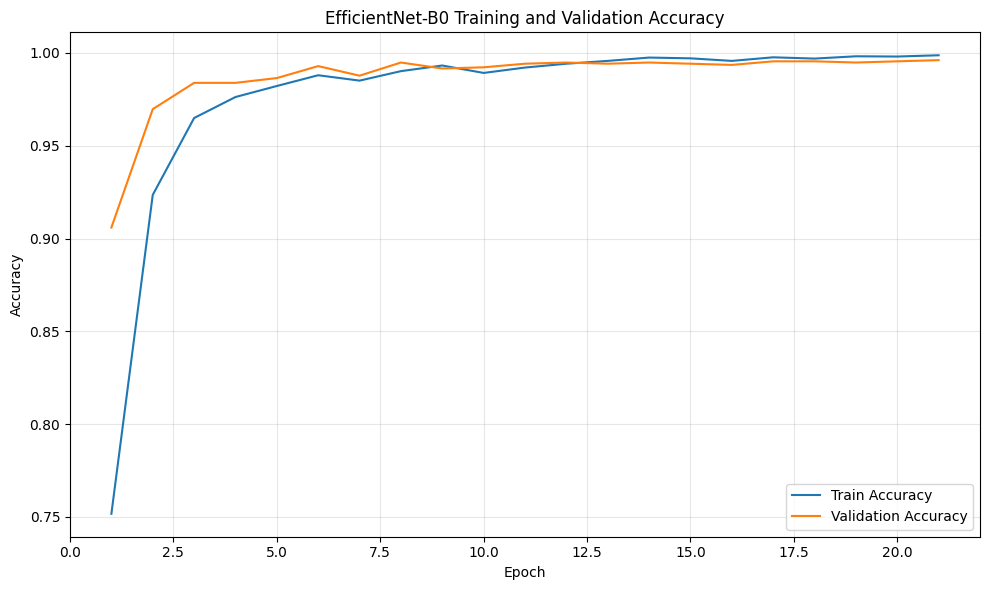

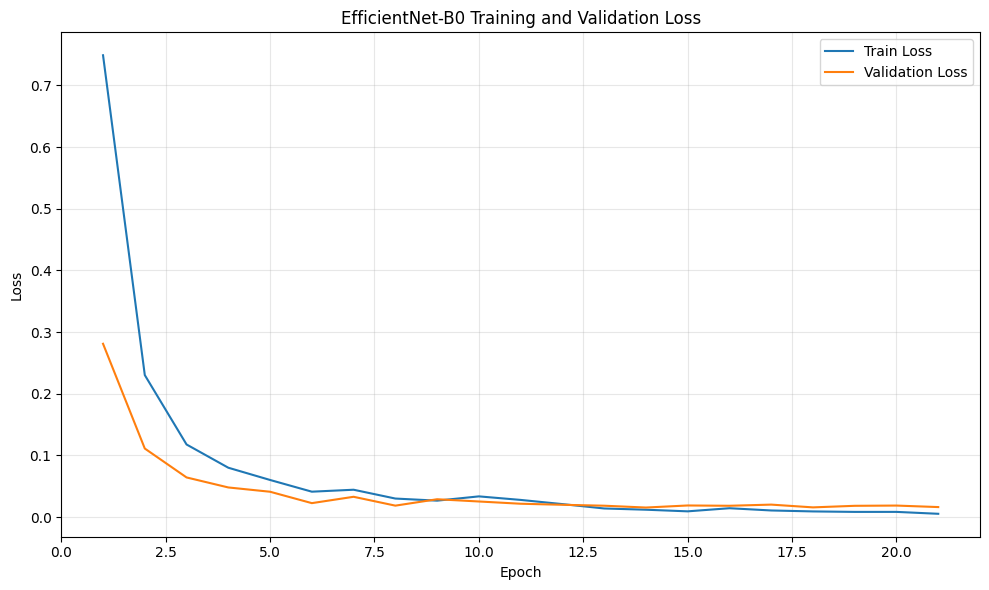

✓ Training curves saved


In [52]:
# ============================================================
# STEP 28 — TRAINING CURVES
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "EfficientNet-B0 Training and Validation Accuracy"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

accuracy_plot = (
    VIS_DIR
    / "training_validation_accuracy.png"
)

plt.savefig(
    accuracy_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "EfficientNet-B0 Training and Validation Loss"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

loss_plot = (
    VIS_DIR
    / "training_validation_loss.png"
)

plt.savefig(
    loss_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "✓ Training curves saved"
)

#  LOAD BEST CHECKPOINT

In [53]:
# ============================================================
# STEP 29 — LOAD BEST CHECKPOINT
# ============================================================

if not BEST_CHECKPOINT.exists():

    raise FileNotFoundError(
        "Best checkpoint does not exist."
    )

checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False
)

MODEL.load_state_dict(
    checkpoint["model_state_dict"]
)

MODEL = MODEL.to(
    DEVICE
)

MODEL.eval()

print("=" * 80)
print("BEST MODEL LOADED")
print("=" * 80)

print(
    "Checkpoint epoch:",
    checkpoint["epoch"]
)

print(
    "Best val loss:",
    checkpoint["best_val_loss"]
)

print(
    "Best val accuracy:",
    checkpoint["best_val_accuracy"]
)

print("\n✓ Model ready for evaluation")

BEST MODEL LOADED
Checkpoint epoch: 14
Best val loss: 0.015476073624029727
Best val accuracy: 0.9948453608247423

✓ Model ready for evaluation


# GENERAL PREDICTION FUNCTION

In [54]:
# ============================================================
# STEP 30 — GENERAL PREDICTION FUNCTION
# ============================================================

@torch.no_grad()
def collect_predictions(
    model,
    loader,
    dataframe,
    device
):

    model.eval()

    all_true = []
    all_pred = []
    all_confidence = []
    all_probabilities = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(
            images
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        confidence, predictions = (
            probabilities.max(
                dim=1
            )
        )

        all_true.extend(
            labels.cpu().numpy()
        )

        all_pred.extend(
            predictions.cpu().numpy()
        )

        all_confidence.extend(
            confidence.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

    result_df = dataframe.reset_index(
        drop=True
    ).copy()

    result_df["true_idx"] = (
        np.array(all_true)
        .astype(int)
    )

    result_df["pred_idx"] = (
        np.array(all_pred)
        .astype(int)
    )

    result_df["true_class"] = (
        result_df["true_idx"]
        .map(IDX_TO_CLASS)
    )

    result_df["pred_class"] = (
        result_df["pred_idx"]
        .map(IDX_TO_CLASS)
    )

    result_df["confidence"] = (
        np.array(all_confidence)
        .astype(float)
    )

    result_df["correct"] = (
        result_df["true_idx"]
        == result_df["pred_idx"]
    )

    probability_array = np.array(
        all_probabilities
    )

    for idx, class_name in enumerate(
        CLASS_NAMES
    ):

        result_df[
            f"prob_{class_name}"
        ] = probability_array[:, idx]

    return result_df


print(
    "✓ Prediction function defined"
)

✓ Prediction function defined


# OVERALL TEST PREDICTION

In [55]:
# ============================================================
# STEP 31 — OVERALL TEST PREDICTION
# ============================================================

test_results = collect_predictions(
    MODEL,
    test_loader,
    test_df,
    DEVICE
)

print("=" * 80)
print("OVERALL TEST PREDICTIONS")
print("=" * 80)

print(
    "Samples:",
    len(test_results)
)

print(
    "Correct:",
    test_results["correct"].sum()
)

print(
    "Incorrect:",
    (~test_results["correct"]).sum()
)

display(
    test_results.head()
)

assert len(test_results) == len(test_df)

print("\n✓ Test predictions complete")

OVERALL TEST PREDICTIONS
Samples: 1871
Correct: 1859
Incorrect: 12


,filename,class,source,country,dataset_group,original_path,true_idx,pred_idx,true_class,pred_class,confidence,correct,prob_Cardboard,prob_Glass,prob_Metal,prob_Paper,prob_Plastic
0,INTL__Metal(118)_aug4.jpg,Metal,International,International,International,/kaggle/input/datasets/kbmhkhan/waste-classifi...,2,2,Metal,Metal,0.998003,True,1.762837e-05,3.103132e-04,0.998003,8.370171e-05,0.001585
1,INTL__Paper(278)_aug3.jpg,Paper,International,International,International,/kaggle/input/datasets/kbmhkhan/waste-classifi...,3,3,Paper,Paper,0.999984,True,1.532918e-06,6.208910e-09,0.000009,9.999840e-01,0.000006
2,BD__BDWaste__BDWaste_Paper__000057.jpg,Paper,Bangladesh,Bangladesh,Bangladesh,/kaggle/working/Bangladesh_5Class_Clean/Paper/...,3,3,Paper,Paper,0.999990,True,4.963996e-06,8.953566e-08,0.000003,9.999897e-01,0.000002
3,INTL__Metal(61)_aug3.jpg,Metal,International,International,International,/kaggle/input/datasets/kbmhkhan/waste-classifi...,2,2,Metal,Metal,0.993846,True,1.327763e-05,5.815482e-03,0.993846,4.246076e-05,0.000282
4,BD__BDWaste__BDWaste_Bottle__000046.jpg,Plastic,Bangladesh,Bangladesh,Bangladesh,/kaggle/working/Bangladesh_5Class_Clean/Plasti...,4,4,Plastic,Plastic,0.999995,True,1.415747e-08,1.267558e-07,0.000004,3.416293e-07,0.999995



✓ Test predictions complete


# BANGLADESH TEST PREDICTION

In [56]:
# ============================================================
# STEP 32 — BANGLADESH TEST PREDICTION
# ============================================================

bd_results = collect_predictions(
    MODEL,
    bd_test_loader,
    bd_test_df,
    DEVICE
)

print("=" * 80)
print("BANGLADESH TEST RESULTS")
print("=" * 80)

print(
    "Samples:",
    len(bd_results)
)

print(
    "Correct:",
    bd_results["correct"].sum()
)

print(
    "Incorrect:",
    (~bd_results["correct"]).sum()
)

assert len(bd_results) == len(
    bd_test_df
)

print("\n✓ Bangladesh evaluation complete")

BANGLADESH TEST RESULTS
Samples: 582
Correct: 572
Incorrect: 10

✓ Bangladesh evaluation complete


# INTERNATIONAL TEST PREDICTION

In [57]:
# ============================================================
# STEP 33 — INTERNATIONAL TEST PREDICTION
# ============================================================

intl_results = collect_predictions(
    MODEL,
    intl_test_loader,
    international_test_df,
    DEVICE
)

print("=" * 80)
print("INTERNATIONAL TEST RESULTS")
print("=" * 80)

print(
    "Samples:",
    len(intl_results)
)

print(
    "Correct:",
    intl_results["correct"].sum()
)

print(
    "Incorrect:",
    (~intl_results["correct"]).sum()
)

assert len(intl_results) == len(
    international_test_df
)

print("\n✓ International evaluation complete")

INTERNATIONAL TEST RESULTS
Samples: 1289
Correct: 1287
Incorrect: 2

✓ International evaluation complete


# OVERALL METRICS

In [58]:
# ============================================================
# STEP 34 — OVERALL METRICS
# ============================================================

y_true = (
    test_results["true_idx"]
    .astype(int)
)

y_pred = (
    test_results["pred_idx"]
    .astype(int)
)

overall_accuracy = accuracy_score(
    y_true,
    y_pred
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

total_samples = len(
    test_results
)

total_errors = int(
    (~test_results["correct"]).sum()
)

error_rate = (
    total_errors
    / total_samples
)

print("=" * 80)
print("OVERALL TEST METRICS")
print("=" * 80)

print(
    f"Accuracy           : "
    f"{overall_accuracy:.4f}"
)

print(
    f"Macro Precision    : "
    f"{macro_precision:.4f}"
)

print(
    f"Macro Recall       : "
    f"{macro_recall:.4f}"
)

print(
    f"Macro F1           : "
    f"{macro_f1:.4f}"
)

print(
    f"Weighted Precision : "
    f"{weighted_precision:.4f}"
)

print(
    f"Weighted Recall    : "
    f"{weighted_recall:.4f}"
)

print(
    f"Weighted F1        : "
    f"{weighted_f1:.4f}"
)

print(
    f"Errors             : "
    f"{total_errors:,}"
)

print(
    f"Error Rate         : "
    f"{error_rate:.4f}"
)

OVERALL TEST METRICS
Accuracy           : 0.9936
Macro Precision    : 0.9930
Macro Recall       : 0.9937
Macro F1           : 0.9933
Weighted Precision : 0.9936
Weighted Recall    : 0.9936
Weighted F1        : 0.9936
Errors             : 12
Error Rate         : 0.0064


# CLASSIFICATION REPORT

In [59]:
# ============================================================
# STEP 35 — CLASSIFICATION REPORT
# ============================================================

report_dict = classification_report(
    y_true,
    y_pred,
    labels=list(
        range(NUM_CLASSES)
    ),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

classification_df = pd.DataFrame(
    report_dict
).T

print("=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)

display(
    classification_df
)

report_csv = (
    REPORT_DIR
    / "classification_report.csv"
)

classification_df.to_csv(
    report_csv
)

print(
    "\nSaved:",
    report_csv
)

CLASSIFICATION REPORT


,precision,recall,f1-score,support
Cardboard,0.985401,0.992647,0.989011,272.000000
Glass,0.994652,1.000000,0.997319,372.000000
Metal,0.997347,0.989474,0.993395,380.000000
Paper,0.995851,0.991736,0.993789,484.000000
Plastic,0.991758,0.994490,0.993122,363.000000
accuracy,0.993586,0.993586,0.993586,0.993586
macro avg,0.993002,0.993669,0.993327,1871.000000
weighted avg,0.993603,0.993586,0.993587,1871.000000



Saved: /kaggle/working/efficientnet_b0_experiment/reports/classification_report.csv


# BANGLADESH vs INTERNATIONAL ACCURACY

In [60]:
# ============================================================
# STEP 36 — GROUP ACCURACY
# ============================================================

bd_accuracy = (
    bd_results["correct"]
    .mean()
)

intl_accuracy = (
    intl_results["correct"]
    .mean()
)

print("=" * 80)
print("SOURCE/GROUP PERFORMANCE")
print("=" * 80)

print(
    f"Overall       : "
    f"{overall_accuracy * 100:.4f}%"
)

print(
    f"Bangladesh    : "
    f"{bd_accuracy * 100:.4f}% "
    f"({len(bd_results):,})"
)

print(
    f"International : "
    f"{intl_accuracy * 100:.4f}% "
    f"({len(intl_results):,})"
)

SOURCE/GROUP PERFORMANCE
Overall       : 99.3586%
Bangladesh    : 98.2818% (582)
International : 99.8448% (1,289)


# CONFUSION MATRIX

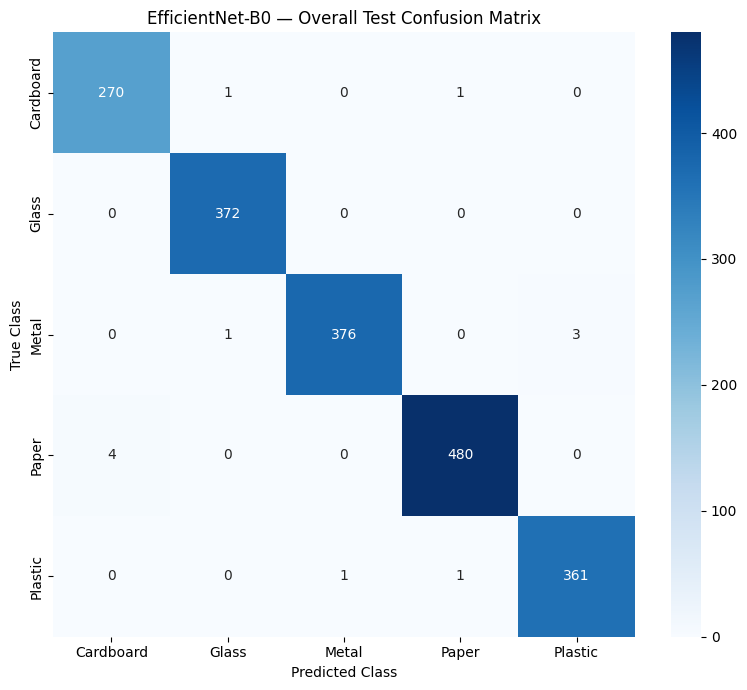

Saved: /kaggle/working/efficientnet_b0_experiment/visualizations/overall_confusion_matrix.png


In [61]:
# ============================================================
# STEP 37 — CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(
        range(NUM_CLASSES)
    )
)

plt.figure(
    figsize=(8, 7)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cmap="Blues"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.title(
    "EfficientNet-B0 — Overall Test Confusion Matrix"
)

plt.tight_layout()

cm_path = (
    VIS_DIR
    / "overall_confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    cm_path
)

# PER-CLASS ACCURACY

In [62]:
# ============================================================
# STEP 38 — PER-CLASS ACCURACY
# ============================================================

per_class_accuracy = {}

for idx, class_name in enumerate(
    CLASS_NAMES
):

    mask = (
        y_true == idx
    )

    if mask.sum() == 0:

        accuracy_value = 0.0

    else:

        accuracy_value = (
            y_pred[mask] == idx
        ).mean()

    per_class_accuracy[
        class_name
    ] = accuracy_value

per_class_df = pd.DataFrame({
    "class": CLASS_NAMES,
    "accuracy": [
        per_class_accuracy[c]
        for c in CLASS_NAMES
    ]
})

print("=" * 80)
print("PER-CLASS ACCURACY")
print("=" * 80)

display(
    per_class_df
)

PER-CLASS ACCURACY


,class,accuracy
0,Cardboard,0.992647
1,Glass,1.000000
2,Metal,0.989474
3,Paper,0.991736
4,Plastic,0.994490


# HIGH-CONFIDENCE ERROR ANALYSIS

In [63]:
# ============================================================
# STEP 39 — HIGH-CONFIDENCE ERROR ANALYSIS
# ============================================================

HIGH_CONF_THRESHOLD = 0.90

test_results["confidence"] = pd.to_numeric(
    test_results["confidence"],
    errors="coerce"
)

high_conf_errors = test_results[
    (~test_results["correct"])
    &
    (
        test_results["confidence"]
        >= HIGH_CONF_THRESHOLD
    )
].copy()

print("=" * 80)
print("HIGH-CONFIDENCE ERROR ANALYSIS")
print("=" * 80)

print(
    f"Threshold            : "
    f"{HIGH_CONF_THRESHOLD:.0%}"
)

print(
    f"Total test samples   : "
    f"{len(test_results):,}"
)

print(
    f"Total errors         : "
    f"{total_errors:,}"
)

print(
    f"High-confidence errors: "
    f"{len(high_conf_errors):,}"
)

if len(high_conf_errors) > 0:

    display(
        high_conf_errors[
            [
                "filename",
                "true_class",
                "pred_class",
                "confidence"
            ]
        ]
        .sort_values(
            "confidence",
            ascending=False
        )
    )

else:

    print(
        "\n✓ No high-confidence errors."
    )

high_conf_csv = (
    REPORT_DIR
    / "high_confidence_errors.csv"
)

high_conf_errors.to_csv(
    high_conf_csv,
    index=False
)

print(
    "\nSaved:",
    high_conf_csv
)

HIGH-CONFIDENCE ERROR ANALYSIS
Threshold            : 90%
Total test samples   : 1,871
Total errors         : 12
High-confidence errors: 5


,filename,true_class,pred_class,confidence
1393,INTL__Paper(413)_aug1.jpg,Paper,Cardboard,0.988904
1855,BD__EWaste__train__IMG_20250805_203244_jpg.rf....,Metal,Plastic,0.986838
1523,BD__EWaste__train__IMG_20250803_220948_jpg.rf....,Plastic,Paper,0.970060
305,BD__EWaste__train__IMG_20250805_204158_jpg.rf....,Metal,Plastic,0.937731
1455,BD__EWaste__train__IMG_20250822_142031_jpg.rf....,Plastic,Metal,0.924307



Saved: /kaggle/working/efficientnet_b0_experiment/reports/high_confidence_errors.csv


# CONFIDENCE STATISTICS

In [64]:
# ============================================================
# STEP 40 — CONFIDENCE STATISTICS
# ============================================================

correct_confidence = (
    test_results[
        test_results["correct"]
    ]["confidence"]
)

incorrect_confidence = (
    test_results[
        ~test_results["correct"]
    ]["confidence"]
)

print("=" * 80)
print("CONFIDENCE STATISTICS")
print("=" * 80)

print(
    f"Mean confidence — correct   : "
    f"{correct_confidence.mean():.4f}"
)

print(
    f"Mean confidence — incorrect : "
    f"{incorrect_confidence.mean():.4f}"
)

print(
    f"Median confidence — correct : "
    f"{correct_confidence.median():.4f}"
)

print(
    f"Median confidence — incorrect: "
    f"{incorrect_confidence.median():.4f}"
)

CONFIDENCE STATISTICS
Mean confidence — correct   : 0.9969
Mean confidence — incorrect : 0.7758
Median confidence — correct : 1.0000
Median confidence — incorrect: 0.7719


# EXPECTED CALIBRATION ERROR

In [65]:
# ============================================================
# STEP 41 — EXPECTED CALIBRATION ERROR
# ============================================================

def calculate_ece(
    confidences,
    predictions,
    labels,
    n_bins=10
):

    confidences = np.asarray(
        confidences
    )

    predictions = np.asarray(
        predictions
    )

    labels = np.asarray(
        labels
    )

    bins = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    ece = 0.0

    for i in range(
        n_bins
    ):

        if i == n_bins - 1:

            mask = (
                (confidences >= bins[i])
                &
                (confidences <= bins[i + 1])
            )

        else:

            mask = (
                (confidences >= bins[i])
                &
                (confidences < bins[i + 1])
            )

        if not np.any(mask):
            continue

        bin_accuracy = np.mean(
            predictions[mask]
            == labels[mask]
        )

        bin_confidence = np.mean(
            confidences[mask]
        )

        bin_fraction = (
            np.sum(mask)
            / len(labels)
        )

        ece += (
            bin_fraction
            * abs(
                bin_accuracy
                - bin_confidence
            )
        )

    return float(ece)


ece = calculate_ece(
    test_results["confidence"].values,
    test_results["pred_idx"].values,
    test_results["true_idx"].values
)

print("=" * 80)
print("CALIBRATION")
print("=" * 80)

print(
    f"ECE: {ece:.6f}"
)

CALIBRATION
ECE: 0.003647


# CONFIDENCE DISTRIBUTION

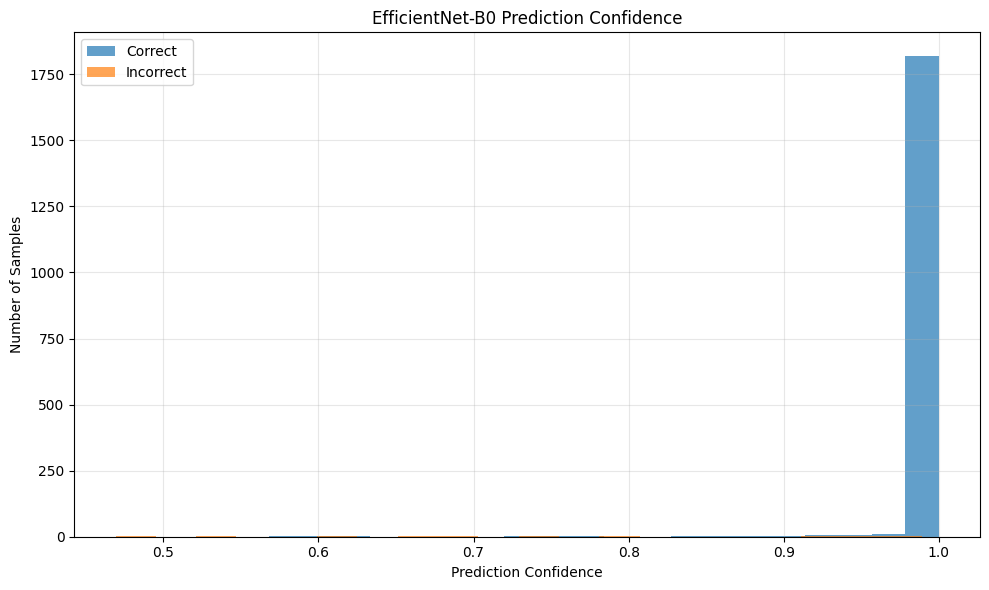

In [66]:
# ============================================================
# STEP 42 — CONFIDENCE DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    correct_confidence,
    bins=20,
    alpha=0.7,
    label="Correct"
)

plt.hist(
    incorrect_confidence,
    bins=20,
    alpha=0.7,
    label="Incorrect"
)

plt.xlabel(
    "Prediction Confidence"
)

plt.ylabel(
    "Number of Samples"
)

plt.title(
    "EfficientNet-B0 Prediction Confidence"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

confidence_path = (
    VIS_DIR
    / "confidence_distribution.png"
)

plt.savefig(
    confidence_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# SAVE TEST PREDICTIONS

In [67]:
# ============================================================
# STEP 43 — SAVE TEST PREDICTIONS
# ============================================================

test_predictions_path = (
    PREDICTION_DIR
    / "efficientnet_b0_test_predictions.csv"
)

test_results.to_csv(
    test_predictions_path,
    index=False
)

bd_predictions_path = (
    PREDICTION_DIR
    / "efficientnet_b0_bangladesh_predictions.csv"
)

bd_results.to_csv(
    bd_predictions_path,
    index=False
)

intl_predictions_path = (
    PREDICTION_DIR
    / "efficientnet_b0_international_predictions.csv"
)

intl_results.to_csv(
    intl_predictions_path,
    index=False
)

print("=" * 80)
print("PREDICTIONS SAVED")
print("=" * 80)

print(
    test_predictions_path
)

print(
    bd_predictions_path
)

print(
    intl_predictions_path
)

PREDICTIONS SAVED
/kaggle/working/efficientnet_b0_experiment/predictions/efficientnet_b0_test_predictions.csv
/kaggle/working/efficientnet_b0_experiment/predictions/efficientnet_b0_bangladesh_predictions.csv
/kaggle/working/efficientnet_b0_experiment/predictions/efficientnet_b0_international_predictions.csv


# COMPLETE RESEARCH SUMMARY

In [68]:
# ============================================================
# STEP 44 — COMPLETE RESEARCH SUMMARY
# ============================================================

summary = {

    "experiment": {
        "model": "EfficientNet-B0",
        "task": "5-class waste classification",
        "seed": SEED,
        "image_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "epochs_configured": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY
    },

    "dataset": {
        "total": len(final_df),
        "train": len(train_df),
        "validation": len(val_df),
        "test": len(test_df),
        "bangladesh_test": len(bd_test_df),
        "international_test": len(
            international_test_df
        ),
        "classes": CLASS_NAMES
    },

    "training": {
        "best_epoch": int(best_epoch),
        "best_validation_loss": float(
            best_val_loss
        ),
        "best_validation_accuracy": float(
            best_val_accuracy
        )
    },

    "overall_test": {
        "accuracy": float(
            overall_accuracy
        ),
        "macro_precision": float(
            macro_precision
        ),
        "macro_recall": float(
            macro_recall
        ),
        "macro_f1": float(
            macro_f1
        ),
        "weighted_precision": float(
            weighted_precision
        ),
        "weighted_recall": float(
            weighted_recall
        ),
        "weighted_f1": float(
            weighted_f1
        ),
        "error_rate": float(
            error_rate
        ),
        "ece": float(
            ece
        ),
        "high_confidence_errors": int(
            len(high_conf_errors)
        )
    },

    "group_performance": {
        "bangladesh_accuracy": float(
            bd_accuracy
        ),
        "international_accuracy": float(
            intl_accuracy
        )
    },

    "model_parameters": {
        "total_parameters": int(
            total_params
        ),
        "trainable_parameters": int(
            trainable_params
        )
    }
}

summary_path = (
    REPORT_DIR
    / "efficientnet_b0_final_summary.json"
)

with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=4,
        ensure_ascii=False
    )

print("=" * 80)
print("EFFICIENTNET-B0 FINAL RESEARCH SUMMARY")
print("=" * 80)

print(
    f"Overall Accuracy       : "
    f"{overall_accuracy * 100:.4f}%"
)

print(
    f"Macro F1               : "
    f"{macro_f1:.4f}"
)

print(
    f"Weighted F1            : "
    f"{weighted_f1:.4f}"
)

print(
    f"Bangladesh Accuracy    : "
    f"{bd_accuracy * 100:.4f}%"
)

print(
    f"International Accuracy : "
    f"{intl_accuracy * 100:.4f}%"
)

print(
    f"ECE                    : "
    f"{ece:.6f}"
)

print(
    f"Misclassified          : "
    f"{total_errors:,}"
)

print(
    f"High-conf errors       : "
    f"{len(high_conf_errors):,}"
)

print(
    "\nSummary saved:",
    summary_path
)

EFFICIENTNET-B0 FINAL RESEARCH SUMMARY
Overall Accuracy       : 99.3586%
Macro F1               : 0.9933
Weighted F1            : 0.9936
Bangladesh Accuracy    : 98.2818%
International Accuracy : 99.8448%
ECE                    : 0.003647
Misclassified          : 12
High-conf errors       : 5

Summary saved: /kaggle/working/efficientnet_b0_experiment/reports/efficientnet_b0_final_summary.json


# FINAL FILE INVENTORY

In [69]:
# ============================================================
# STEP 45 — FINAL FILE INVENTORY
# ============================================================

print("=" * 80)
print("EFFICIENTNET-B0 EXPERIMENT FILES")
print("=" * 80)

for path in sorted(
    OUTPUT_ROOT.rglob("*")
):

    if path.is_file():

        size_mb = (
            path.stat().st_size
            / (1024 * 1024)
        )

        print(
            f"{path.relative_to(OUTPUT_ROOT)} "
            f"— {size_mb:.2f} MB"
        )

print("\n✓ Experiment completed")

EFFICIENTNET-B0 EXPERIMENT FILES
checkpoints/efficientnet_b0_best.pth — 46.40 MB
checkpoints/efficientnet_b0_last.pth — 46.40 MB
predictions/efficientnet_b0_bangladesh_predictions.csv — 0.21 MB
predictions/efficientnet_b0_international_predictions.csv — 0.36 MB
predictions/efficientnet_b0_test_predictions.csv — 0.54 MB
reports/classification_report.csv — 0.00 MB
reports/efficientnet_b0_final_summary.json — 0.00 MB
reports/high_confidence_errors.csv — 0.00 MB
reports/training_history.csv — 0.00 MB
visualizations/confidence_distribution.png — 0.10 MB
visualizations/overall_confusion_matrix.png — 0.13 MB
visualizations/training_validation_accuracy.png — 0.15 MB
visualizations/training_validation_loss.png — 0.14 MB

✓ Experiment completed


# FINAL SANITY CHECK

In [70]:
# ============================================================
# STEP 46 — FINAL SANITY CHECK
# ============================================================

print("=" * 80)
print("FINAL SANITY CHECK")
print("=" * 80)

checks = {

    "Final dataset = 10668":
        len(final_df) == 10668,

    "Train = 7245":
        len(train_df) == 7245,

    "Validation = 1552":
        len(val_df) == 1552,

    "Test = 1871":
        len(test_df) == 1871,

    "BD test = 582":
        len(bd_test_df) == 582,

    "International = 1289":
        len(international_test_df) == 1289,

    "Group total = test":
        (
            len(bd_test_df)
            + len(international_test_df)
            == len(test_df)
        ),

    "Prediction total = test":
        len(test_results) == len(test_df),

    "All predictions finite":
        np.isfinite(
            test_results["confidence"]
        ).all(),

    "Best checkpoint exists":
        BEST_CHECKPOINT.exists(),

    "Summary exists":
        summary_path.exists()
}

all_passed = True

for name, passed in checks.items():

    symbol = "✓" if passed else "✗"

    print(
        f"{symbol} {name}"
    )

    if not passed:
        all_passed = False

print("-" * 80)

if not all_passed:

    raise RuntimeError(
        "Final sanity check failed."
    )

print(
    "✓ ALL FINAL CHECKS PASSED"
)

print(
    "\nEfficientNet-B0 experiment is ready "
    "for research comparison."
)

FINAL SANITY CHECK
✓ Final dataset = 10668
✓ Train = 7245
✓ Validation = 1552
✓ Test = 1871
✓ BD test = 582
✓ International = 1289
✓ Group total = test
✓ Prediction total = test
✓ All predictions finite
✓ Best checkpoint exists
✓ Summary exists
--------------------------------------------------------------------------------
✓ ALL FINAL CHECKS PASSED

EfficientNet-B0 experiment is ready for research comparison.
